In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df=pd.read_csv('/content/Credit Card Customer Data.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sl_No                660 non-null    int64
 1   Customer Key         660 non-null    int64
 2   Avg_Credit_Limit     660 non-null    int64
 3   Total_Credit_Cards   660 non-null    int64
 4   Total_visits_bank    660 non-null    int64
 5   Total_visits_online  660 non-null    int64
 6   Total_calls_made     660 non-null    int64
dtypes: int64(7)
memory usage: 36.2 KB


In [5]:
df.shape

(660, 7)

In [6]:
df.describe()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
count,660.000000,660.000000,660.000000,660.000000,660.000000,660.000000,660.000000
mean,330.500000,55141.443939,34574.242424,4.706061,2.403030,2.606061,3.583333
std,190.669872,25627.772200,37625.487804,2.167835,1.631813,2.935724,2.865317
min,1.000000,11265.000000,3000.000000,1.000000,0.000000,0.000000,0.000000
25%,165.750000,33825.250000,10000.000000,3.000000,1.000000,1.000000,1.000000
50%,330.500000,53874.500000,18000.000000,5.000000,2.000000,2.000000,3.000000
75%,495.250000,77202.500000,48000.000000,6.000000,4.000000,4.000000,5.000000
max,660.000000,99843.000000,200000.000000,10.000000,5.000000,15.000000,10.000000


In [7]:
df.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


In [8]:
x=df.drop(['Sl_No','Customer Key'], axis=1)

In [9]:
x.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,100000,2,1,1,0
1,50000,3,0,10,9
2,50000,7,1,3,4
3,30000,5,1,1,4
4,100000,6,0,12,3


In [10]:
from sklearn.preprocessing import StandardScaler
SS=StandardScaler()
x_scaled=SS.fit_transform(x)

In [11]:
from sklearn.cluster import KMeans
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)

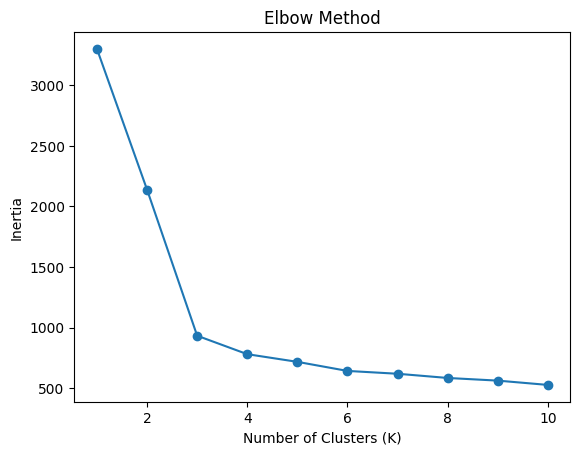

In [12]:
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [13]:
k=3

In [14]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(x_scaled)
df['KMeans_Cluster'] = kmeans_labels

In [15]:
df['KMeans_Cluster'].value_counts()

,count
KMeans_Cluster,
0,386
2,224
1,50


In [16]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples=5)
dbscan_labels = dbscan.fit_predict(x_scaled)
df['DBSCAN_Cluster'] = dbscan_labels

In [17]:
df['DBSCAN_Cluster'].value_counts()

,count
DBSCAN_Cluster,
0,606
-1,44
1,10


In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_scaled)

In [19]:
X_pca.shape

(660, 2)

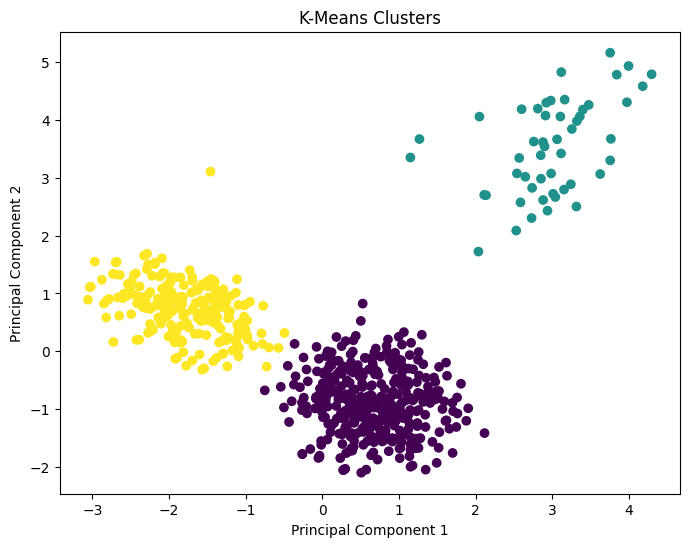

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    cmap='viridis'
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clusters')

plt.show()

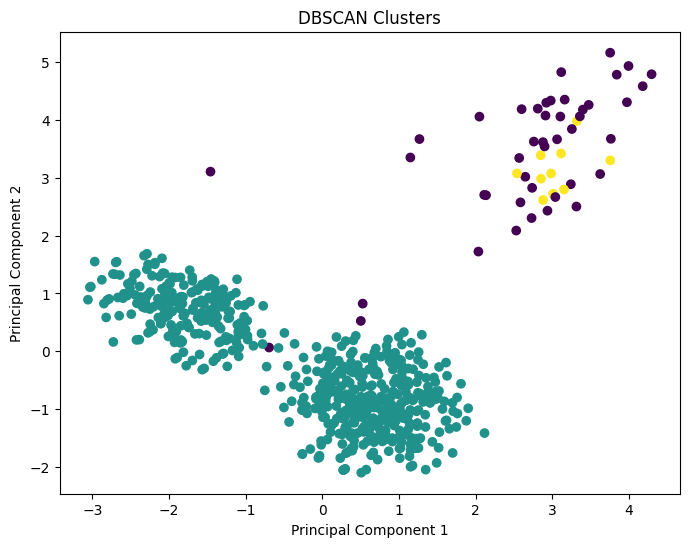

In [21]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dbscan_labels,
    cmap='viridis'
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('DBSCAN Clusters')

plt.show()

In [23]:
from sklearn.metrics import silhouette_score
kmeans_score = silhouette_score(x_scaled, kmeans_labels)
print("K-Means Silhouette Score:", kmeans_score)

K-Means Silhouette Score: 0.5157182558881063


In [25]:
mask = dbscan_labels != -1

dbscan_score = silhouette_score(
    x_scaled[mask],
    dbscan_labels[mask]
)

print("DBSCAN Silhouette Score:", dbscan_score)

DBSCAN Silhouette Score: 0.5445315927655981


After scaling the features, K-Means and DBSCAN produced different customer segmentations. Using the elbow method, K-Means identified 3 clusters and assigned every customer to one of those clusters. The PCA visualization shows three relatively distinct groups.

DBSCAN identified 2 clusters and 44 noise points. Most customers (606) belonged to one large cluster, while 10 customers formed a smaller cluster. Unlike K-Means, DBSCAN did not force every observation into a cluster and classified low-density observations as noise.

The K-Means silhouette score was 0.516, while DBSCAN achieved 0.545 when the noise points were excluded. Although DBSCAN had a slightly higher silhouette score for its non-noise observations, the scores are not directly equivalent because DBSCAN's noise points were excluded. The PCA plots show that K-Means produced three broader customer segments, whereas DBSCAN emphasized dense regions and identified unusual observations as noise.